CONVERTING CSV TO IMAGE AND DISPLAYING

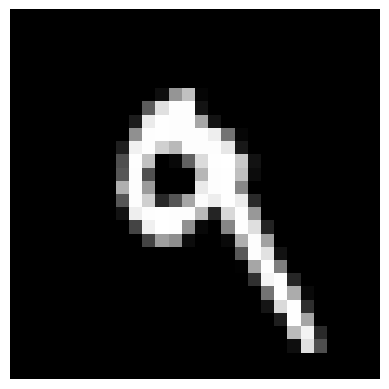

In [ ]:
import pandas as pd
from PIL import Image, ImageOps
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# Step 1: Load the MNIST dataset and save images
csv_file = "/content/mnist_test.csv"  # Replace with the provided file name
data = pd.read_csv(csv_file)

labels = data.iloc[:, 0]  # First column: Labels
pixels = data.iloc[:, 1:]  # Remaining columns: Pixel data

# Directory to save images
output_dir = "mnist_images/"
os.makedirs(output_dir, exist_ok=True)

for idx, (label, pixel_values) in enumerate(zip(labels, pixels.values)):
    image_array = pixel_values.reshape(28, 28).astype(np.uint8)
    img = Image.fromarray(image_array)
    img.save(f"{output_dir}/{label}_{idx}.png")
    if idx >= 10:  # Save only 10 images for testing
        break

# Step 2: Select and display a random image
image_files = [f for f in os.listdir(output_dir) if f.endswith(".png")]
random_image_file = random.choice(image_files)
random_image_path = os.path.join(output_dir, random_image_file)
random_img = Image.open(random_image_path)

# Display the image in Google Colab
plt.imshow(random_img, cmap="gray")
plt.axis('off')  # Hide axes for better view
plt.show()




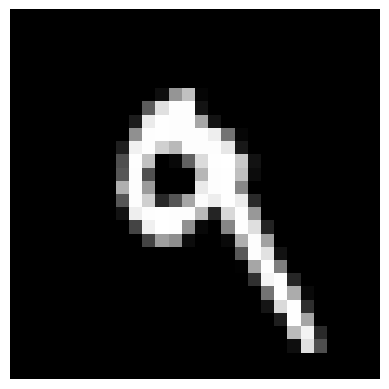

In [ ]:
# Step 3: Convert the image to grayscale
grayscale_img = random_img.convert("L")

# Display the grayscale image
plt.imshow(grayscale_img, cmap="gray")
plt.axis('off')
plt.show()




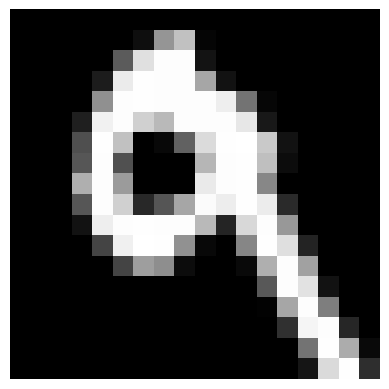

In [ ]:
# Step 4: Crop the image
cropped_img = grayscale_img.crop((5, 5, 23, 23))  # Cropping to a smaller region

# Display the cropped image
plt.imshow(cropped_img, cmap="gray")
plt.axis('off')
plt.show()



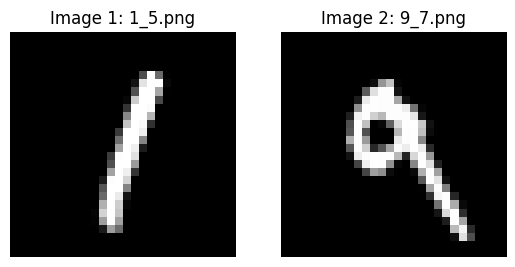

In [ ]:
image_files = [f for f in os.listdir(output_dir) if f.endswith(".png")]
image1_file = random.choice(image_files)
image2_file = random.choice(image_files)

# Load two images
image1_path = os.path.join(output_dir, image1_file)
image2_path = os.path.join(output_dir, image2_file)

img1 = Image.open(image1_path)
img2 = Image.open(image2_path)

# Display the two images
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap="gray")
plt.axis('off')
plt.title(f"Image 1: {image1_file}")

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap="gray")
plt.axis('off')
plt.title(f"Image 2: {image2_file}")

plt.show()


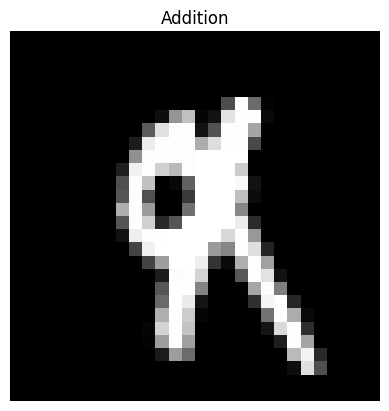

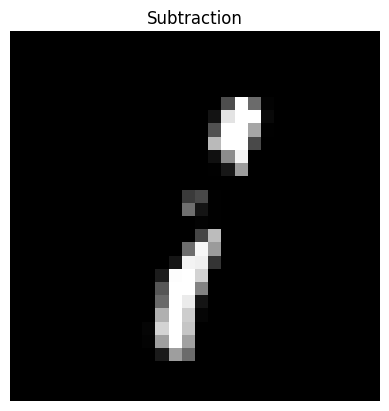

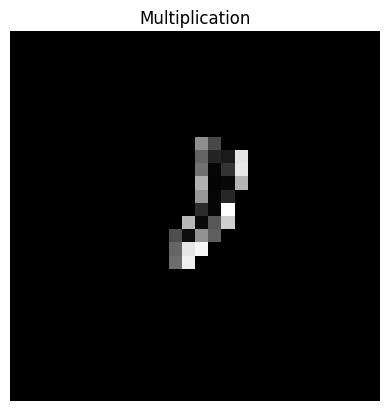

<ipython-input-5-d15a320b3542>:37: RuntimeWarning: divide by zero encountered in divide
  divided_img = Image.fromarray(np.divide(np.array(img1_resized), img2_array).astype(np.uint8))
<ipython-input-5-d15a320b3542>:37: RuntimeWarning: invalid value encountered in divide
  divided_img = Image.fromarray(np.divide(np.array(img1_resized), img2_array).astype(np.uint8))
<ipython-input-5-d15a320b3542>:37: RuntimeWarning: invalid value encountered in cast
  divided_img = Image.fromarray(np.divide(np.array(img1_resized), img2_array).astype(np.uint8))


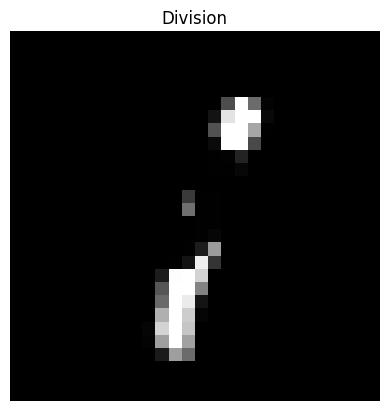

In [ ]:
from PIL import ImageChops

# Step 3: Convert both images to grayscale (if not already)
img1_gray = img1.convert("L")
img2_gray = img2.convert("L")

# Step 4: Perform Arithmetic Operations between the two images

# 1. Image Addition (Add corresponding pixel values of image1 and image2)
added_img = ImageChops.add(img1_gray, img2_gray)
plt.imshow(added_img, cmap="gray")
plt.axis('off')
plt.title("Addition")
plt.show()

# 2. Image Subtraction (Subtract pixel values of image2 from image1)
subtracted_img = ImageChops.subtract(img1_gray, img2_gray)
plt.imshow(subtracted_img, cmap="gray")
plt.axis('off')
plt.title("Subtraction")
plt.show()

# 3. Image Multiplication (Multiply corresponding pixel values of image1 and image2)
# First, ensure both images have the same size
img1_resized = img1_gray.resize(img2_gray.size)
img2_resized = img2_gray.resize(img1_gray.size)

multiplied_img = Image.fromarray(np.multiply(np.array(img1_resized), np.array(img2_resized)).astype(np.uint8))
plt.imshow(multiplied_img, cmap="gray")
plt.axis('off')
plt.title("Multiplication")
plt.show()

# 4. Image Division (Divide pixel values of image1 by image2)
# Avoid division by zero by adding a small constant to image2
img2_array = np.array(img2_resized) + 1  # To prevent division by zero
divided_img = Image.fromarray(np.divide(np.array(img1_resized), img2_array).astype(np.uint8))
plt.imshow(divided_img, cmap="gray")
plt.axis('off')
plt.title("Division")
plt.show()

# **IMAGE NEGATIVE**

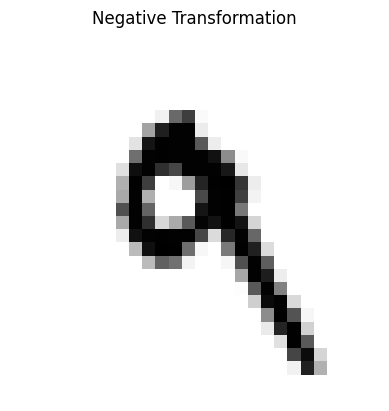

In [ ]:
# Step 3: Image Negative Transformation
def negative_transformation(image):
    image_array = np.array(image)
    negative_image = 255 - image_array  # Invert the pixel values (negative transformation)
    return Image.fromarray(negative_image)

# Apply Negative Transformation on the selected random image
negative_img = negative_transformation(random_img)

# Display the Negative Image
plt.imshow(negative_img, cmap='gray')
plt.title("Negative Transformation")
plt.axis('off')
plt.show()



# **THRESHOLDING**

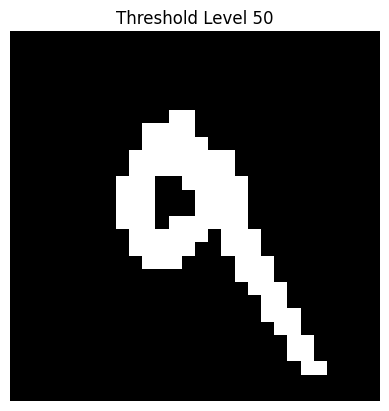

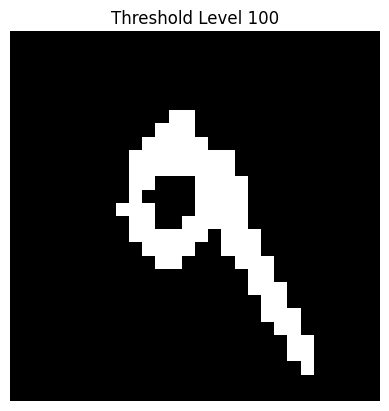

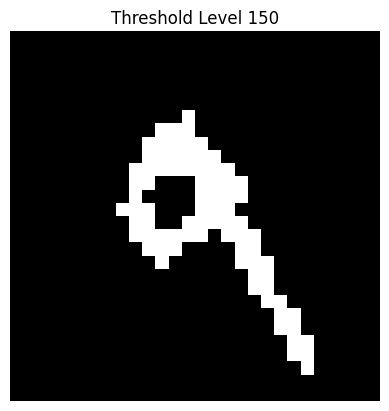

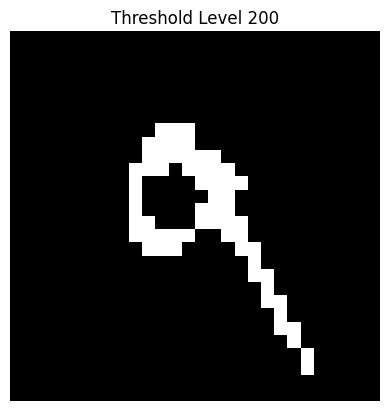

In [ ]:
# Step 4: Image Thresholding at Various Levels
def threshold_image(image, threshold_value):
    image_array = np.array(image)
    thresholded_image = np.where(image_array > threshold_value, 255, 0)  # Apply thresholding
    # Ensure the result is in uint8 format before creating the image
    thresholded_image = thresholded_image.astype(np.uint8)
    return Image.fromarray(thresholded_image)

# Display thresholded images with different levels
threshold_levels = [50, 100, 150, 200]
for level in threshold_levels:
    thresholded_img = threshold_image(random_img, level)
    plt.imshow(thresholded_img, cmap='gray')
    plt.title(f"Threshold Level {level}")
    plt.axis('off')
    plt.show()


# **GRAY LEVEL SLICING**

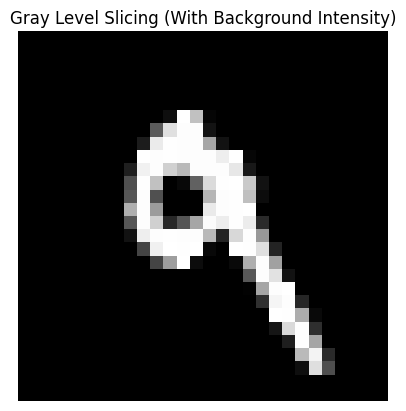

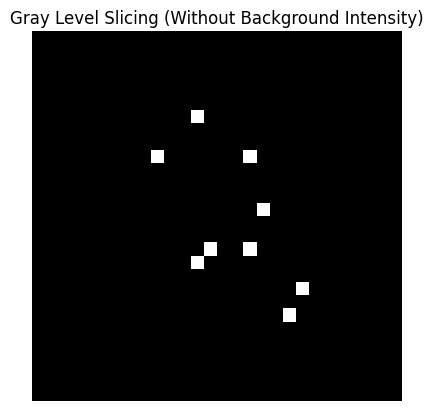

In [ ]:
def gray_level_slicing(image, min_value, max_value, background_intensity=True):
    image_array = np.array(image)

    # Apply slicing: pixels within the range are set to 255 (white), others are unchanged
    sliced_image = np.where((image_array >= min_value) & (image_array <= max_value), 255, image_array)

    # If background intensity is False, set background pixels to black (0)
    if not background_intensity:
        sliced_image = np.where((image_array < min_value) | (image_array > max_value), 0, sliced_image)

    return Image.fromarray(sliced_image.astype(np.uint8))

# Slicing the image with and without background intensity slicing
min_value, max_value = 100, 150  # Range for gray level slicing

# With background intensity (original values outside the range remain unchanged)
sliced_img_with_bg = gray_level_slicing(random_img, min_value, max_value, background_intensity=True)
plt.imshow(sliced_img_with_bg, cmap='gray')
plt.title("Gray Level Slicing (With Background Intensity)")
plt.axis('off')
plt.show()

# Without background intensity (everything outside the range becomes black)
sliced_img_without_bg = gray_level_slicing(random_img, min_value, max_value, background_intensity=False)
plt.imshow(sliced_img_without_bg, cmap='gray')
plt.title("Gray Level Slicing (Without Background Intensity)")
plt.axis('off')
plt.show()


In [ ]:
img_array = np.array(random_img)
print(f"Original image pixel range: {img_array.min()} to {img_array.max()}")


Original image pixel range: 0 to 255


# **CONTRAST STRETCHING**

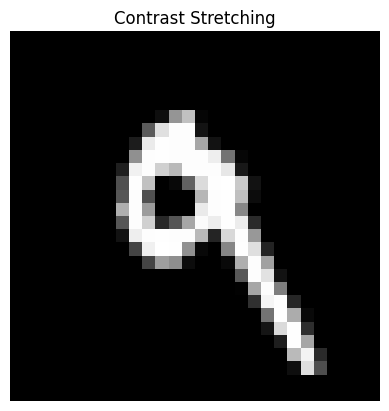

In [ ]:
def contrast_stretching(image):
    img_array = np.array(image)
    min_pixel, max_pixel = img_array.min(), img_array.max()
    stretched_img = ((img_array - min_pixel) / (max_pixel - min_pixel)) * 255
    stretched_img = np.uint8(stretched_img)
    return Image.fromarray(stretched_img)

contrast_stretched_img = contrast_stretching(random_img)

# Display the contrast-stretched image
plt.imshow(contrast_stretched_img, cmap='gray')
plt.title("Contrast Stretching")
plt.axis('off')
plt.show()

# **LOG TRANSFORMATION**

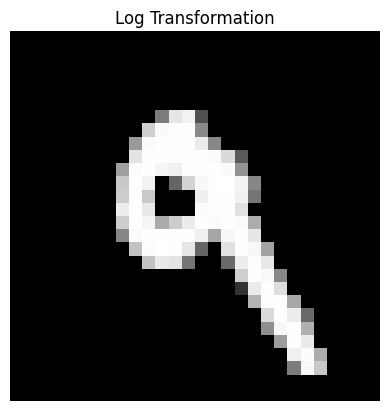

In [ ]:
# Step 4: Apply Log Transformation
def log_transformation(image, c=1):
    img_array = np.array(image, dtype=float)
    # Apply log transformation: c * log(1 + pixel_value)
    log_img = c * np.log(1 + img_array)
    log_img = np.uint8(np.interp(log_img, (log_img.min(), log_img.max()), (0, 255)))
    return Image.fromarray(log_img)

log_transformed_img = log_transformation(random_img)
# Display the log-transformed image
plt.imshow(log_transformed_img, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()

# **POWER LAW**

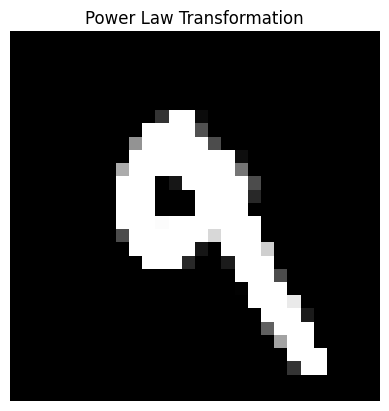

In [ ]:
# Step 5: Apply Power Law Transformation
def power_law_transformation(image, gamma=1):
    img_array = np.array(image, dtype=float)
    # Apply power law transformation: pixel_value ** gamma
    power_img = np.uint8(np.interp(np.power(img_array, gamma), (img_array.min(), img_array.max()), (0, 255)))
    return Image.fromarray(power_img)

power_law_img = power_law_transformation(random_img, gamma=1.5)

# Display the power law transformed image
plt.imshow(power_law_img, cmap='gray')
plt.title("Power Law Transformation")
plt.axis('off')
plt.show()


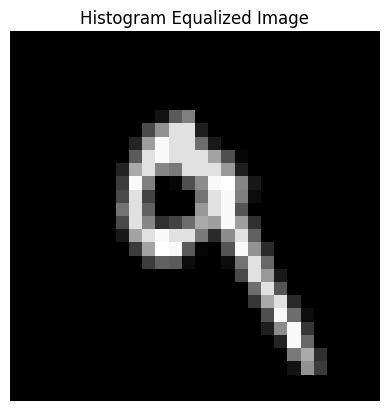

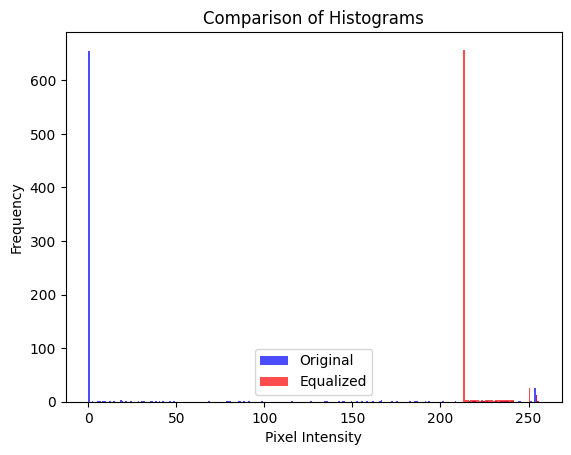

Observation:
After histogram equalization, the pixel intensities are redistributed to span a broader range, enhancing the contrast of the image.


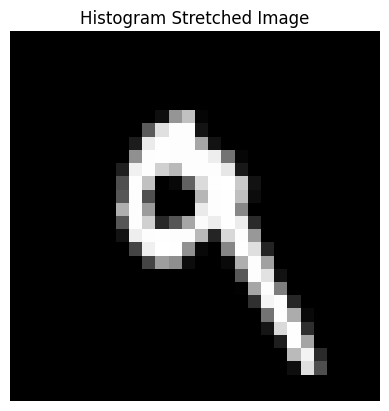

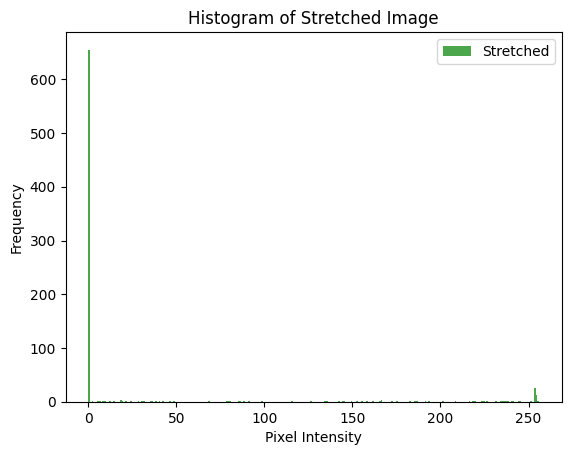

Observation:
Histogram stretching increases the dynamic range of pixel intensities to span 0-255, making the image contrast more noticeable without altering the overall shape of the histogram.


In [ ]:
def histogram_equalization(image):
    image_array = np.array(image)
    flat = image_array.flatten()  # Flatten the image array
    hist, bins = np.histogram(flat, bins=256, range=[0, 256])
    cdf = hist.cumsum()  # Cumulative distribution function
    cdf_normalized = cdf * (255 / cdf[-1])  # Normalize CDF to [0, 255]
    equalized_image = cdf_normalized[flat].reshape(image_array.shape).astype(np.uint8)
    return Image.fromarray(equalized_image), hist, cdf_normalized

equalized_img, original_hist, equalized_cdf = histogram_equalization(random_img)

# Display the equalized image
plt.imshow(equalized_img, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis('off')
plt.show()

# Step 5: Show Histograms
# Original Histogram
plt.hist(np.array(random_img).flatten(), bins=256, range=[0, 256], color='blue', alpha=0.7, label="Original")
plt.hist(np.array(equalized_img).flatten(), bins=256, range=[0, 256], color='red', alpha=0.7, label="Equalized")
plt.title("Comparison of Histograms")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Step 6: Note Observations
print("Observation:")
print("After histogram equalization, the pixel intensities are redistributed to span a broader range, enhancing the contrast of the image.")

# Step 7: Perform Histogram Stretching
def histogram_stretching(image):
    image_array = np.array(image)
    min_val, max_val = np.min(image_array), np.max(image_array)
    stretched = ((image_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return Image.fromarray(stretched)

stretched_img = histogram_stretching(random_img)

# Display the stretched image
plt.imshow(stretched_img, cmap="gray")
plt.title("Histogram Stretched Image")
plt.axis('off')
plt.show()

# Display histogram of stretched image
plt.hist(np.array(stretched_img).flatten(), bins=256, range=[0, 256], color='green', alpha=0.7, label="Stretched")
plt.title("Histogram of Stretched Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# Step 8: Observations on Stretching
print("Observation:")
print("Histogram stretching increases the dynamic range of pixel intensities to span 0-255, making the image contrast more noticeable without altering the overall shape of the histogram.")


# **HIGH PASS & HIGH BOOST**

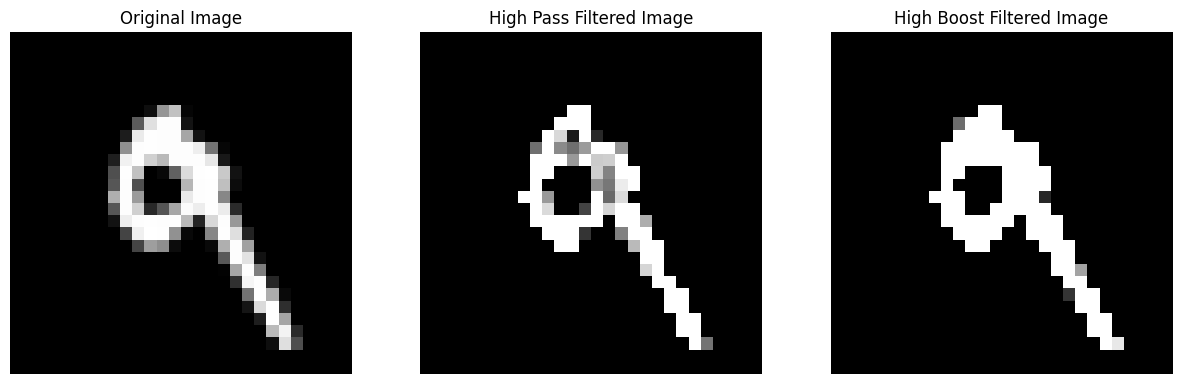

In [ ]:
# Convert the random image to a numpy array for processing
random_image_array = np.array(random_img, dtype=np.float32)

# Step 3: Apply Basic High Pass Filter
def high_pass_filter(image_array):
    kernel = np.array([[-1, -1, -1],
                       [-1,  8, -1],
                       [-1, -1, -1]])  # High-pass filter kernel
    filtered_image = np.zeros_like(image_array)

    # Perform convolution without padding
    for i in range(1, image_array.shape[0] - 1):
        for j in range(1, image_array.shape[1] - 1):
            region = image_array[i-1:i+2, j-1:j+2]
            filtered_image[i, j] = np.sum(region * kernel)

    # Clip values to maintain valid intensity range
    filtered_image = np.clip(filtered_image, 0, 255)
    return filtered_image

# Apply high-pass filter
high_pass_result = high_pass_filter(random_image_array)

# Step 4: Apply Basic High Boost Filter
def high_boost_filter(image_array, boost_factor=1.5):
    kernel = np.array([[-1, -1, -1],
                       [-1,  8 + boost_factor, -1],
                       [-1, -1, -1]])  # High-boost filter kernel
    filtered_image = np.zeros_like(image_array)

    # Perform convolution without padding
    for i in range(1, image_array.shape[0] - 1):
        for j in range(1, image_array.shape[1] - 1):
            region = image_array[i-1:i+2, j-1:j+2]
            filtered_image[i, j] = np.sum(region * kernel)

    # Clip values to maintain valid intensity range
    filtered_image = np.clip(filtered_image, 0, 255)
    return filtered_image

# Apply high-boost filter
high_boost_result = high_boost_filter(random_image_array)

# Display the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(random_image_array, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

# High-pass filtered image
axes[1].imshow(high_pass_result, cmap="gray")
axes[1].set_title("High Pass Filtered Image")
axes[1].axis("off")

# High-boost filtered image
axes[2].imshow(high_boost_result, cmap="gray")
axes[2].set_title("High Boost Filtered Image")
axes[2].axis("off")

plt.show()


# **IDEAL HIGH PASS, LOW PASS,GAUSSIAN**

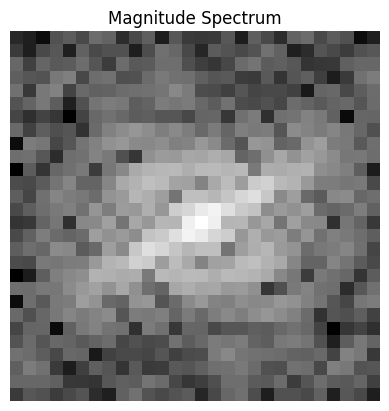

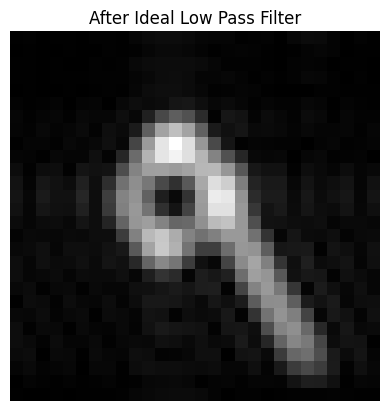

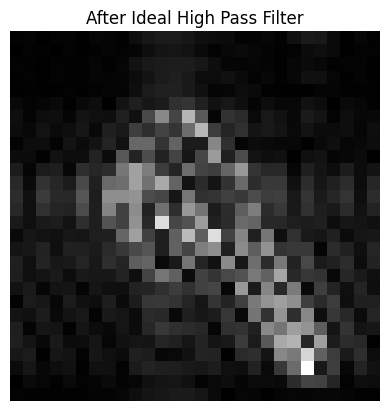

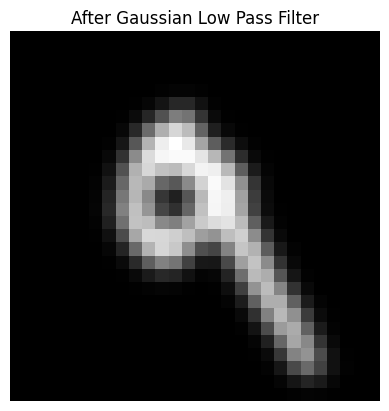

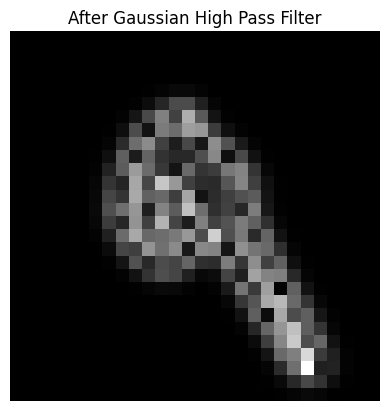

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 3: Convert the random image to a numpy array
image_array = np.array(random_img)

# Step 4: Getting the Fourier Transform of the image
f = np.fft.fft2(image_array)  # Compute the 2D Fourier Transform
fshift = np.fft.fftshift(f)  # Shift zero frequency component to the center
magnitude_spectrum = np.log(np.abs(fshift) + 1)

# Display the magnitude spectrum of the Fourier Transformed image
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis('off')
plt.show()

# Step 5: Ideal Low Pass Filter
def ideal_low_pass_filter(size, cutoff_radius):
    rows, cols = size
    crow, ccol = rows // 2, cols // 2  # Center of the image
    mask = np.zeros((rows, cols), dtype=np.float32)  # Create a mask
    mask[crow - cutoff_radius:crow + cutoff_radius, ccol - cutoff_radius:ccol + cutoff_radius] = 1
    return mask

# Apply Ideal Low Pass Filter
cutoff_radius = 5  # You can change this value for different cutoff frequencies
lp_filter = ideal_low_pass_filter(image_array.shape, cutoff_radius)
fshift_lp = fshift * lp_filter

# Inverse Fourier Transform of the filtered image
f_ishift_lp = np.fft.ifftshift(fshift_lp)
img_back_lp = np.fft.ifft2(f_ishift_lp)
img_back_lp = np.abs(img_back_lp)  # Take absolute value for real image

# Display the filtered image (Ideal Low Pass Filter)
plt.imshow(img_back_lp, cmap='gray')
plt.title("After Ideal Low Pass Filter")
plt.axis('off')
plt.show()

# Step 6: Ideal High Pass Filter
def ideal_high_pass_filter(size, cutoff_radius):
    rows, cols = size
    crow, ccol = rows // 2, cols // 2  # Center of the image
    mask = np.ones((rows, cols), dtype=np.float32)  # Create a mask with ones
    mask[crow - cutoff_radius:crow + cutoff_radius, ccol - cutoff_radius:ccol + cutoff_radius] = 0
    return mask

# Apply Ideal High Pass Filter
hp_filter = ideal_high_pass_filter(image_array.shape, cutoff_radius)
fshift_hp = fshift * hp_filter

# Inverse Fourier Transform of the filtered image
f_ishift_hp = np.fft.ifftshift(fshift_hp)
img_back_hp = np.fft.ifft2(f_ishift_hp)
img_back_hp = np.abs(img_back_hp)

# Display the filtered image (Ideal High Pass Filter)
plt.imshow(img_back_hp, cmap='gray')
plt.title("After Ideal High Pass Filter")
plt.axis('off')
plt.show()

# Step 7: Gaussian Low Pass Filter
def gaussian_low_pass_filter(size, cutoff_radius):
    rows, cols = size
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            mask[i, j] = np.exp(-((i - crow) ** 2 + (j - ccol) ** 2) / (2 * (cutoff_radius ** 2)))
    return mask

# Apply Gaussian Low Pass Filter
gaussian_lp_filter = gaussian_low_pass_filter(image_array.shape, cutoff_radius)
fshift_glp = fshift * gaussian_lp_filter

# Inverse Fourier Transform of the filtered image
f_ishift_glp = np.fft.ifftshift(fshift_glp)
img_back_glp = np.fft.ifft2(f_ishift_glp)
img_back_glp = np.abs(img_back_glp)

# Display the filtered image (Gaussian Low Pass Filter)
plt.imshow(img_back_glp, cmap='gray')
plt.title("After Gaussian Low Pass Filter")
plt.axis('off')
plt.show()

# Step 8: Gaussian High Pass Filter
def gaussian_high_pass_filter(size, cutoff_radius):
    return 1 - gaussian_low_pass_filter(size, cutoff_radius)

# Apply Gaussian High Pass Filter
gaussian_hp_filter = gaussian_high_pass_filter(image_array.shape, cutoff_radius)
fshift_ghp = fshift * gaussian_hp_filter

# Inverse Fourier Transform of the filtered image
f_ishift_ghp = np.fft.ifftshift(fshift_ghp)
img_back_ghp = np.fft.ifft2(f_ishift_ghp)
img_back_ghp = np.abs(img_back_ghp)

# Display the filtered image (Gaussian High Pass Filter)
plt.imshow(img_back_ghp, cmap='gray')
plt.title("After Gaussian High Pass Filter")
plt.axis('off')
plt.show()


# **REGION GROWING,SPLITTING,MERGING**

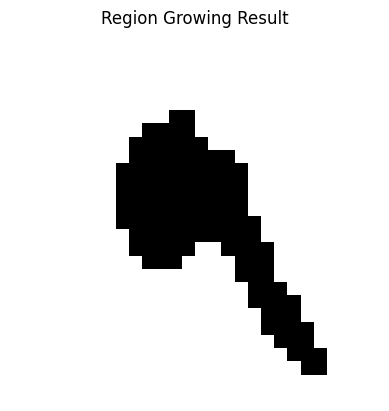

Splitting region: (0, 0, 28, 28), Mean Intensity: 26.864795918367346


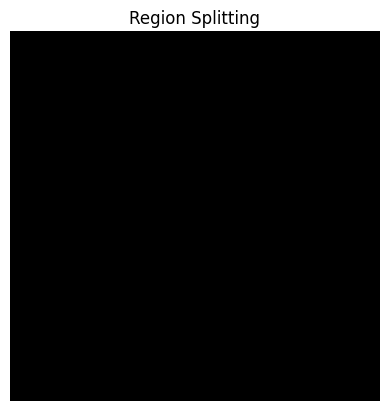

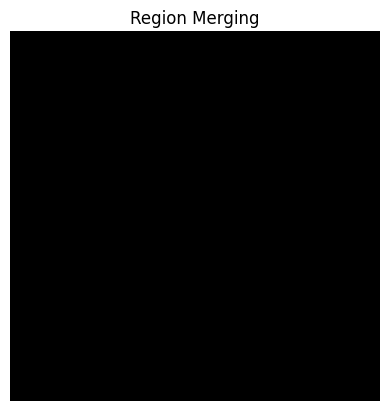

In [ ]:
# Convert the selected random image to a numpy array for processing
image_array = np.array(random_img)

# Step 3: Implement Region Growing
def region_growing(image, seed, threshold):
    """
    Perform region growing from a seed pixel based on intensity threshold.
    """
    # Initialize a binary mask with all zeros
    mask = np.zeros_like(image, dtype=np.uint8)

    # Get image dimensions
    rows, cols = image.shape

    # List of pixels to be processed, starting with the seed
    pixel_list = [seed]

    # Get the intensity of the seed pixel
    seed_intensity = image[seed[0], seed[1]]

    # Directions for 4-connectivity (up, down, left, right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while pixel_list:
        x, y = pixel_list.pop()

        # Mark the current pixel as part of the region
        mask[x, y] = 255

        # Explore neighboring pixels
        for dx, dy in directions:
            nx, ny = x + dx, y + dy

            # Check if within bounds and if the pixel has not been visited yet
            if 0 <= nx < rows and 0 <= ny < cols and mask[nx, ny] == 0:
                # If the intensity difference is less than the threshold, add to the region
                if abs(image[nx, ny] - seed_intensity) < threshold:
                    pixel_list.append((nx, ny))

    return mask

# Choose a random seed pixel for region growing
seed_pixel = (random.randint(0, image_array.shape[0] - 1), random.randint(0, image_array.shape[1] - 1))
threshold = 20  # Define a threshold value for region growing

# Perform region growing
region_mask = region_growing(image_array, seed_pixel, threshold)

# Display the result of region growing
plt.imshow(region_mask, cmap="gray")
plt.title("Region Growing Result")
plt.axis('off')
plt.show()

# Step 4: Region Splitting with debugging
def region_splitting(image, threshold):
    """
    Performs region splitting based on intensity difference.
    """
    rows, cols = image.shape
    regions = [(0, 0, rows, cols)]  # Start with the whole image as a region
    split_regions = []

    while regions:
        r1, c1, r2, c2 = regions.pop()
        region = image[r1:r2, c1:c2]
        region_mean = np.mean(region)

        print(f"Splitting region: ({r1}, {c1}, {r2}, {c2}), Mean Intensity: {region_mean}")

        # If the region's intensity difference is larger than the threshold, split it
        if np.all(abs(region - region_mean) > threshold):
            # Split the region into 4 quadrants
            mid_row = (r1 + r2) // 2
            mid_col = (c1 + c2) // 2
            regions.append((r1, c1, mid_row, mid_col))
            regions.append((r1, mid_col, mid_row, c2))
            regions.append((mid_row, c1, r2, mid_col))
            regions.append((mid_row, mid_col, r2, c2))
        else:
            split_regions.append((r1, c1, r2, c2))  # Keep the current region if it's homogeneous

    return split_regions

# Step 5: Region Merging with debugging
def region_merging(image, regions, threshold):
    """
    Merges regions based on similarity of their mean intensities.
    """
    merged_image = np.zeros_like(image)

    for r1, c1, r2, c2 in regions:
        region = image[r1:r2, c1:c2]
        region_mean = np.mean(region)

        for other_r1, other_c1, other_r2, other_c2 in regions:
            if (r1 != other_r1 or c1 != other_c1 or r2 != other_r2 or c2 != other_c2):
                other_region = image[other_r1:other_r2, other_c1:other_c2]
                other_mean = np.mean(other_region)

                print(f"Comparing regions: ({r1}, {c1}, {r2}, {c2}) vs ({other_r1}, {other_c1}, {other_r2}, {other_c2}), "
                      f"Mean Intensities: {region_mean} vs {other_mean}")

                # Merge regions if their intensity difference is below the threshold
                if abs(region_mean - other_mean) < threshold:
                    merged_image[r1:r2, c1:c2] = 255
                    merged_image[other_r1:other_r2, other_c1:other_c2] = 255
    return merged_image

# Perform region splitting
split_regions = region_splitting(image_array, threshold)

# Display the split regions
split_image = np.zeros_like(image_array)

for r1, c1, r2, c2 in split_regions:
    split_image[r1:r2, c1:c2] = 255  # Mark regions in white

plt.imshow(split_image, cmap="gray")
plt.title("Region Splitting")
plt.axis('off')
plt.show()

# Perform region merging
merged_image = region_merging(image_array, split_regions, threshold)

# Display the merged regions
plt.imshow(merged_image, cmap="gray")
plt.title("Region Merging")
plt.axis('off')
plt.show()


# **EROSION,DILATION,OPENING, CLOSING**

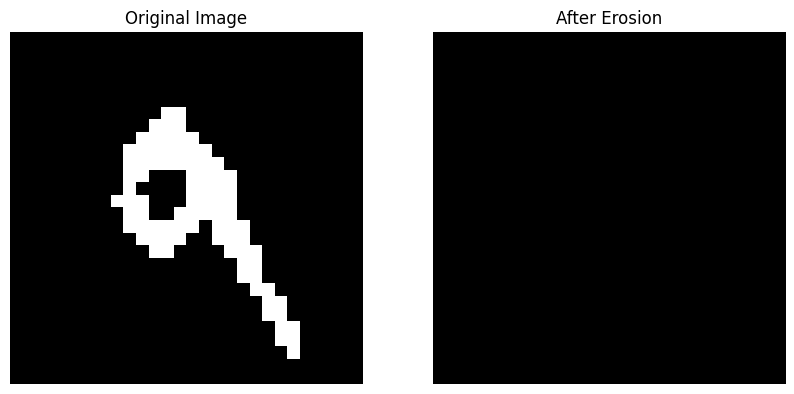

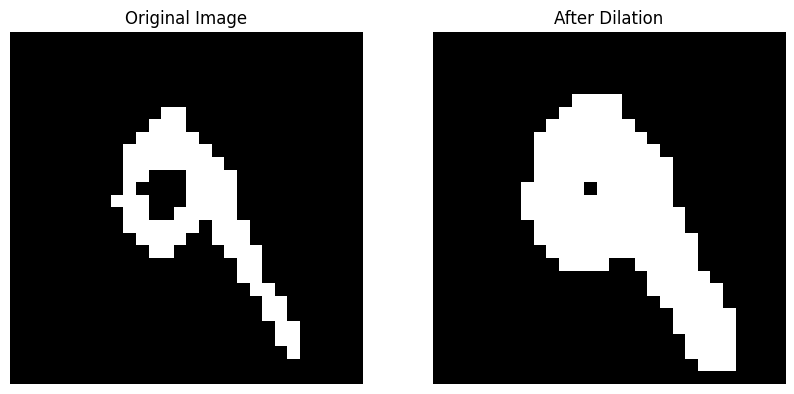

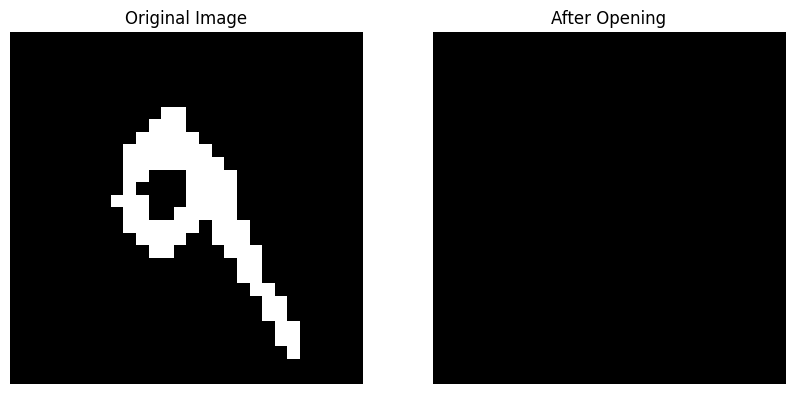

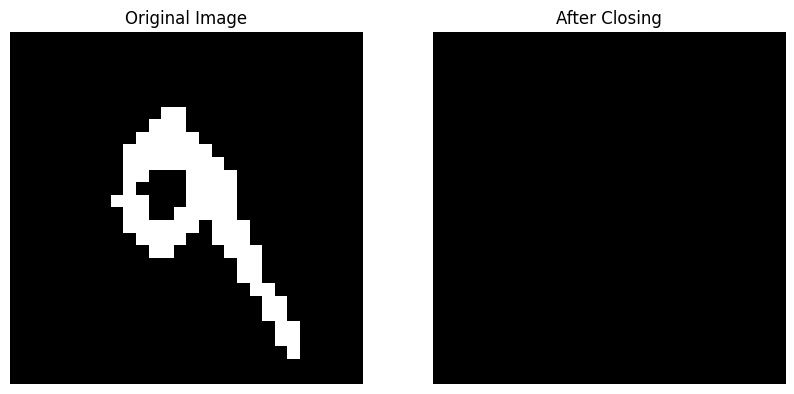

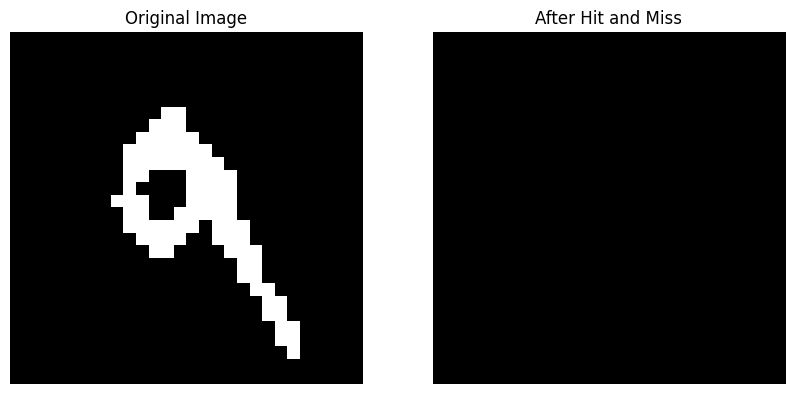

In [ ]:

# Convert the image to grayscale if needed
gray_img = random_img.convert('L')

# Convert the grayscale image to a binary image
binary_img = np.array(gray_img)
binary_img = np.where(binary_img > 128, 255, 0)  # Convert to binary (0 or 255)

# Step 3: Define a structuring element (3x3 square kernel)
kernel = np.ones((3, 3), dtype=np.uint8)

# Function to apply erosion
def erosion(binary_img, kernel):
    output = np.zeros_like(binary_img)
    # Apply the kernel to each pixel
    for i in range(1, binary_img.shape[0] - 1):
        for j in range(1, binary_img.shape[1] - 1):
            region = binary_img[i-1:i+2, j-1:j+2]
            if np.all(region == kernel):  # Check if the region matches the kernel
                output[i, j] = 255
    return output

# Function to apply dilation
def dilation(binary_img, kernel):
    output = np.zeros_like(binary_img)
    for i in range(1, binary_img.shape[0] - 1):
        for j in range(1, binary_img.shape[1] - 1):
            region = binary_img[i-1:i+2, j-1:j+2]
            if np.any(region == 255):  # If any pixel in the region is 255
                output[i, j] = 255
    return output

# Function to apply opening (erosion followed by dilation)
def opening(binary_img, kernel):
    eroded = erosion(binary_img, kernel)
    return dilation(eroded, kernel)

# Function to apply closing (dilation followed by erosion)
def closing(binary_img, kernel):
    dilated = dilation(binary_img, kernel)
    return erosion(dilated, kernel)

# Function for hit and miss
def hit_and_miss(binary_img, kernel):
    complement_kernel = np.ones_like(kernel) - kernel  # Negation of the kernel
    eroded_img = erosion(binary_img, kernel)
    complement_eroded_img = erosion(255 - binary_img, complement_kernel)
    return eroded_img & complement_eroded_img

# Step 4: Apply morphological operations and display results
# Erosion
erosion_img = erosion(binary_img, kernel)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(erosion_img, cmap='gray')
plt.title("After Erosion")
plt.axis('off')
plt.show()

# Dilation
dilation_img = dilation(binary_img, kernel)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dilation_img, cmap='gray')
plt.title("After Dilation")
plt.axis('off')
plt.show()

# Opening (erosion followed by dilation)
opening_img = opening(binary_img, kernel)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(opening_img, cmap='gray')
plt.title("After Opening")
plt.axis('off')
plt.show()

# Closing (dilation followed by erosion)
closing_img = closing(binary_img, kernel)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(closing_img, cmap='gray')
plt.title("After Closing")
plt.axis('off')
plt.show()

# Hit and Miss
hit_miss_img = hit_and_miss(binary_img, kernel)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hit_miss_img, cmap='gray')
plt.title("After Hit and Miss")
plt.axis('off')
plt.show()